# Code to AI — Week 6, Day 3: Practice Lab
**Netflix Project — Guided Build**

---

This is the scaffolded version of today's project. The cleaning steps are written out for
you with short gaps to fill; the **insights are entirely yours to write**.

Work through it, then use what you learn here to write your own version from scratch in
the assignment.

> **Working in Google Colab?**
> Colab does not see the files on your computer. Run the cell below **first** to upload
> `netflix_titles.csv`, then skip the `read_csv('data/...')` cell and use this one instead.
>
> If you are running locally in VS Code, ignore this and use the normal loading cell.

In [ ]:
# ONLY run this if you are on Google Colab.
# It opens a file picker - choose your netflix_titles.csv

# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('netflix_titles.csv')
# print("Shape:", df.shape)

---
## Part A — Load and inspect

In [1]:
import pandas as pd

# The CSV lives in the data/ folder next to this notebook
df = pd.read_csv('data/netflix_titles.csv')

print("Loaded successfully!")
print("Shape:", df.shape)

Loaded successfully!
Shape: (8612, 12)


### Task A1

Print the shape, then `.head()`, then `.info()`.

In [7]:
# Your code here
df.shape

(8612, 12)

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8612 entries, 0 to 8611
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8612 non-null   str  
 1   type          8612 non-null   str  
 2   title         8612 non-null   str  
 3   director      6214 non-null   str  
 4   cast          7840 non-null   str  
 5   country       7835 non-null   str  
 6   date_added    8601 non-null   str  
 7   release_year  8612 non-null   int64
 8   rating        8608 non-null   str  
 9   duration      8609 non-null   str  
 10  listed_in     8612 non-null   str  
 11  description   8612 non-null   str  
dtypes: int64(1), str(11)
memory usage: 807.5 KB


In [6]:
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s8365,TV Show,Lost Kingdom,NaN,"Diego Sato, Yuki Wang, Raj Tanaka, Liam Brown,...",India,"June 16, 2020",2019,TV-MA,1 Season,"British TV Shows, TV Dramas",A gripping story about love.
1,s5294,TV Show,Lost Summer,NaN,"Diego Kumar, Diego Tanaka, Raj Garcia, Maria Ali",United States,"November 14, 2009",2007,TV-Y,1 Season,Anime Series,A sweeping story about revenge.
2,s6931,Movie,Frozen Empire II,Grace Hassan,"Omar Kumar, Fatima Khan, Chen Ali, Liam Khan",United States,"January 5, 2008",2003,NR,97 min,Horror Movies,A sweeping story about survival.
3,s7760,Movie,Endless Empire Forever,Yuki Sato,"Maria Khan, Fatima Garcia, Chen Tanaka",India,"September 15, 2014",2011,R,102 min,"Documentaries, International Movies",A hilarious story about family.
4,s3313,TV Show,Burning Dream,NaN,"Raj Wilson, Elena Wang, John Brown, Chen Wang,...",India,"April 10, 2008",2003,TV-Y7,1 Season,Docuseries,A sweeping story about ambition.


### Task A2 — Missing-value report

Build the `report` DataFrame with `missing_count` and `missing_percent`,
showing only columns with missing data.

In [12]:
# Your code here
report = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': (df.isnull().mean() * 100).round(1)
})
report = report[report['missing_count'] > 0]
report = report.sort_values('missing_percent', ascending=False)

report

,missing_count,missing_percent
director,2398,27.8
cast,772,9.0
country,777,9.0
date_added,11,0.1
rating,4,0.0
duration,3,0.0


<details>
<summary>Hint</summary>

```python
report = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': (df.isnull().mean() * 100).round(1)
})
report = report[report['missing_count'] > 0].sort_values('missing_percent', ascending=False)
```
</details>

---
## Part B — Clean (scaffolded)

### Task B1 — Working copy

In [13]:
clean = df.copy()
print("Copy made:", len(clean), "rows")

Copy made: 8612 rows


### Task B2 — Duplicates

Print the duplicate count, remove them, print before/after row counts.

In [16]:
clean.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s8365,TV Show,Lost Kingdom,NaN,"Diego Sato, Yuki Wang, Raj Tanaka, Liam Brown,...",India,"June 16, 2020",2019,TV-MA,1 Season,"British TV Shows, TV Dramas",A gripping story about love.


In [14]:
# Your code here
print("duplicates row", clean.duplicated().sum())

duplicates row 12


### Task B3 — Strip whitespace

Loop over the text columns and apply `.str.strip()` to each.

In [20]:
text_columns = ['type', 'title', 'director', 'cast', 'country', 'rating', 'listed_in']

# Your code here - loop over text_columns
for col in text_columns:
    clean[col] = clean[col].str.strip()

print("Whitespace stripped", text_columns)    

Whitespace stripped ['type', 'title', 'director', 'cast', 'country', 'rating', 'listed_in']


### Task B5 — Drop the unfixable rows

Drop rows missing `date_added`, `rating` or `duration`. Print how many rows this cost,
and what percentage of the data that was.

In [28]:
# Your code here 
rows_before = len(clean)

clean = clean.dropna(subset=['date_added', 'rating', 'duration'])

print("Before:", rows_before)
print("After: ", len(clean))
print("Dropped:", rows_before - len(clean), "rows")
print()
print("That is", round((rows_before - len(clean)) / rows_before * 100, 2), "% of the data - acceptable.")




Before: 8594
After:  8594
Dropped: 0 rows

That is 0.0 % of the data - acceptable.


### Task B6 — Convert the date

Convert `date_added` with `pd.to_datetime(..., format='mixed')`, then create
`year_added` from it.

In [29]:
# Your code here
# Your code here
clean['date_added'] = pd.to_datetime(clean['date_added'], format='mixed')
clean['year_added'] = clean['date_added'].dt.year

print(clean[['date_added', 'year_added']].head())

  date_added  year_added
0 2020-06-16        2020
1 2009-11-14        2009
2 2008-01-05        2008
3 2014-09-15        2014
4 2008-04-10        2008


### Task B7 — Split the duration

Split `duration` into `duration_number` (numeric) and `duration_unit`.

In [34]:
# Your code here
parts = clean['duration'].str.split(' ', expand=True)
clean['duration_number'] = pd.to_numeric(parts[0])
clean['duration_unit'] = parts[1]
print(parts)

        0       1
0       1  Season
1       1  Season
2      97     min
3     102     min
4       1  Season
...   ...     ...
8607  109     min
8608  107     min
8609   84     min
8610   92     min
8611    1  Season

[8594 rows x 2 columns]


<details>
<summary>Hint</summary>

```python
parts = clean['duration'].str.split(' ', expand=True)
clean['duration_number'] = pd.to_numeric(parts[0])
clean['duration_unit'] = parts[1]
```
</details>

In [33]:
print(clean[['duration', 'duration_number', 'duration_unit']].head())


   duration  duration_number duration_unit
0  1 Season                1        Season
1  1 Season                1        Season
2    97 min               97           min
3   102 min              102           min
4  1 Season                1        Season


### Task B8 — Verify

Print the total missing values remaining. It should be 0.

In [35]:
# Your code here
print("total missing values remaining:", clean.isnull().sum())

total missing values remaining: show_id               0
type                  0
title                 0
director           2393
cast                771
country             777
date_added            0
release_year          0
rating                0
duration              0
listed_in             0
description           0
year_added            0
duration_number       0
duration_unit         0
dtype: int64


---
## Part C — Insights (all yours)

No hints from here on. This is the part that goes in your portfolio.

### Task C1 — Movies vs TV Shows

Count them, and also show the percentages.

In [ ]:
# Your code here
counts = clean['type'].value_counts()
percentages = clean['type'].value_counts(normalize=True) * 100

print(counts)
print()
print(percentages.round(2))

type
Movie      6036
TV Show    2558
Name: count, dtype: int64

type
Movie      70.24
TV Show    29.76
Name: proportion, dtype: float64


### Task C2 — Top 10 countries

In [37]:
# Your code here
print(clean['country'].value_counts().head(10))

country
United States     2661
India             1324
United Kingdom     698
Canada             440
Japan              355
France             336
South Korea        315
Spain              265
Mexico             258
Australia          220
Name: count, dtype: int64


### Task C3 — Titles added per year

Sorted by year, not by count.

In [38]:
# Your code here
titles_per_year = clean['year_added'].value_counts().sort_index()
print(titles_per_year)

year_added
2008    1478
2009     320
2010     376
2011     437
2012     440
2013     485
2014     445
2015     470
2016     465
2017     475
2018     445
2019     424
2020     406
2021    1928
Name: count, dtype: int64


### Task C4 — Movie duration statistics

Filter to movies only, then print the average, median, shortest and longest duration.

**Careful:** do not average across both types. Minutes and seasons are different units.

In [39]:
# Your code here
movies = clean[clean['type'] == 'Movie']
movie_durations = movies['duration_number']

print("Average:", movie_durations.mean())
print("Median:", movie_durations.median())
print("Shortest:", movie_durations.min())
print("Longest:", movie_durations.max())

Average: 98.68124585818423
Median: 98.0
Shortest: 45
Longest: 183


### Task C5 — TV show seasons

Now filter to TV shows and find the most common number of seasons.

In [40]:
# Your code here
tv_shows = clean[clean['type'] == 'TV Show']
print("Most common number of seasons:", tv_shows['duration_number'].mode()[0])

Most common number of seasons: 1


### Task C6 — Your own question

Ask one question of this dataset that nobody told you to ask. Write it here, then
answer it with code below.

**My question:**

In [41]:
# Your code here# My question: Kaun se director ne sabse zyada titles diye hain Netflix par?
print(clean['director'].value_counts().head(5))


director
Elena Brown      40
Sofia Lopez      38
Fatima Hassan    38
Omar Novak       37
Yuki Garcia      36
Name: count, dtype: int64


---
## Part D — Chart and save

### Task D1 — One bar chart

Chart the titles added per year with a single `.plot(kind='bar')` call.
Give it a title and axis labels.

<Axes: title={'center': 'Titles Added to Netflix Per Year'}, xlabel='Year', ylabel='Number of Titles'>

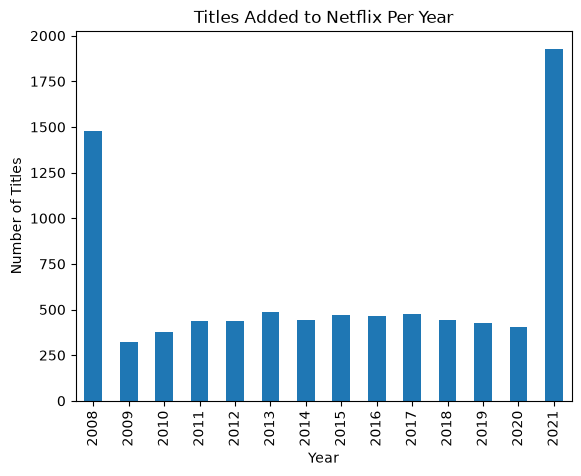

In [44]:
# Your code here
titles_per_year.plot(kind='bar', title='Titles Added to Netflix Per Year', xlabel='Year', ylabel='Number of Titles')

### Task D2 — Save the cleaned CSV

Save as `netflix_clean.csv` with `index=False`, then read it back to confirm it worked.

In [45]:
# Your code here
clean.to_csv('netflix_clean.csv', index=False)

# Confirm it worked
check = pd.read_csv('netflix_clean.csv')
print(check.shape)
print(check.head())

(8594, 15)
  show_id     type                   title      director  \
0   s8365  TV Show            Lost Kingdom           NaN   
1   s5294  TV Show             Lost Summer           NaN   
2   s6931    Movie        Frozen Empire II  Grace Hassan   
3   s7760    Movie  Endless Empire Forever     Yuki Sato   
4   s3313  TV Show           Burning Dream           NaN   

                                                cast        country  \
0  Diego Sato, Yuki Wang, Raj Tanaka, Liam Brown,...          India   
1   Diego Kumar, Diego Tanaka, Raj Garcia, Maria Ali  United States   
2       Omar Kumar, Fatima Khan, Chen Ali, Liam Khan  United States   
3             Maria Khan, Fatima Garcia, Chen Tanaka          India   
4  Raj Wilson, Elena Wang, John Brown, Chen Wang,...          India   

   date_added  release_year rating  duration  \
0  2020-06-16          2019  TV-MA  1 Season   
1  2009-11-14          2007   TV-Y  1 Season   
2  2008-01-05          2003     NR    97 min   
3  2014-0

---
## Done!

You now have a working cleaning pipeline and your own insights. Take this into the
assignment and write it from scratch — that is where it really sticks. 💪